In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2C3E50',
    'profit'   : '#27AE60',
    'revenue'  : '#2980B9',
    'cost'     : '#E74C3C',
    'warning'  : '#F39C12',
    'highlight': '#8E44AD'
}

# matplotlib's default font can't render emoji glyphs (shows as tofu boxes
# in legends), so quadrant labels here are plain text
QUADRANT_COLORS = {
    'STAR'        : '#27AE60',
    'HIDDEN GEM'  : '#2980B9',
    'VOLUME TRAP' : '#F39C12',
    'DEAD WEIGHT' : '#E74C3C'
}

In [2]:
df = pd.read_csv('../data/nassau_candy_enriched.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f"Data loaded: {df.shape[0]} rows")

Data loaded: 6013 rows


### Prepare Product Summary

In [3]:
total_revenue = df['Sales'].sum()
total_profit  = df['Gross Profit'].sum()

product_summary = df.groupby(['Product Name', 'Division', 'Factory', 'Quadrant']).agg(
    Total_Revenue       = ('Sales', 'sum'),
    Total_Profit        = ('Gross Profit', 'sum'),
    Total_Units         = ('Units', 'sum'),
    Avg_Margin          = ('Gross_Margin_%', 'mean'),
    Avg_Profit_per_Unit = ('Profit_per_Unit', 'mean')
).round(2).reset_index()

product_summary['Profit_Share_%'] = (
    product_summary['Total_Profit'] / total_profit * 100
).round(2)

print(f"Products ready: {len(product_summary)}")

Products ready: 15


### Chart 5: Top 15 Products by Gross Profit

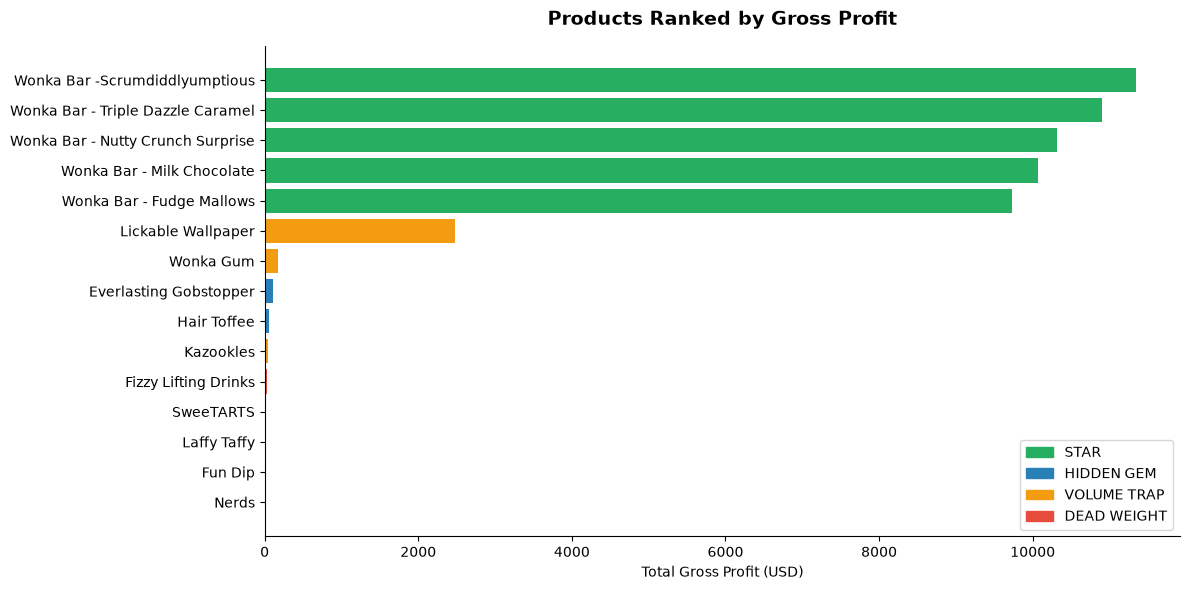

Chart 5 saved


In [4]:
ranked_profit = product_summary.sort_values('Total_Profit', ascending=True)

colors = [QUADRANT_COLORS[q] for q in ranked_profit['Quadrant']]

fig, ax = plt.subplots()

ax.barh(ranked_profit['Product Name'], ranked_profit['Total_Profit'], color=colors)

ax.set_title('Products Ranked by Gross Profit', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Gross Profit (USD)')
ax.set_ylabel('')

# Legend for quadrants
legend_handles = [
    plt.Rectangle((0,0), 1, 1, color=color, label=quadrant)
    for quadrant, color in QUADRANT_COLORS.items()
]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/05_product_gross_profit_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

### Chart 6: Top 15 Products by Gross Margin %

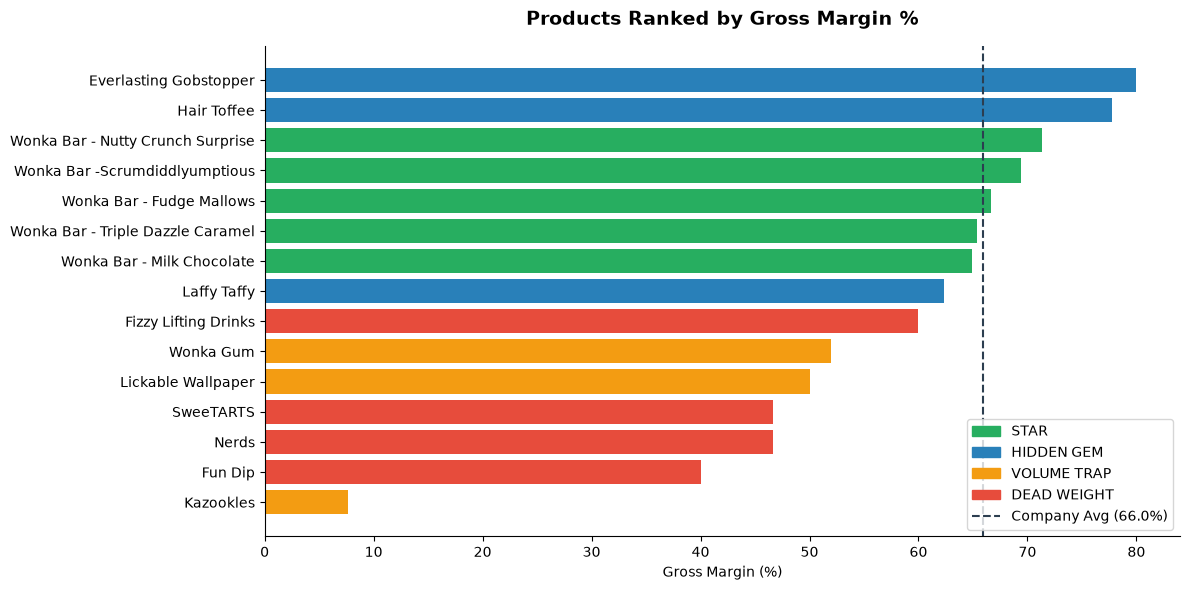

Chart 6 saved


In [5]:
ranked_margin = product_summary.sort_values('Avg_Margin', ascending=True)

colors = [QUADRANT_COLORS[q] for q in ranked_margin['Quadrant']]

fig, ax = plt.subplots()

ax.barh(ranked_margin['Product Name'], ranked_margin['Avg_Margin'], color=colors)

# Company average reference line
company_avg_margin = (total_profit / total_revenue * 100)
ax.axvline(x=company_avg_margin, color=COLORS['primary'],
           linestyle='--', linewidth=1.5, label=f'Company Avg ({company_avg_margin:.1f}%)')

ax.set_title('Products Ranked by Gross Margin %', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gross Margin (%)')
ax.set_ylabel('')

legend_handles = [
    plt.Rectangle((0,0), 1, 1, color=color, label=quadrant)
    for quadrant, color in QUADRANT_COLORS.items()
]
legend_handles.append(
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--', label=f'Company Avg ({company_avg_margin:.1f}%)')
)
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/06_product_margin_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

### Chart 7: Product Quadrant Scatter Plot

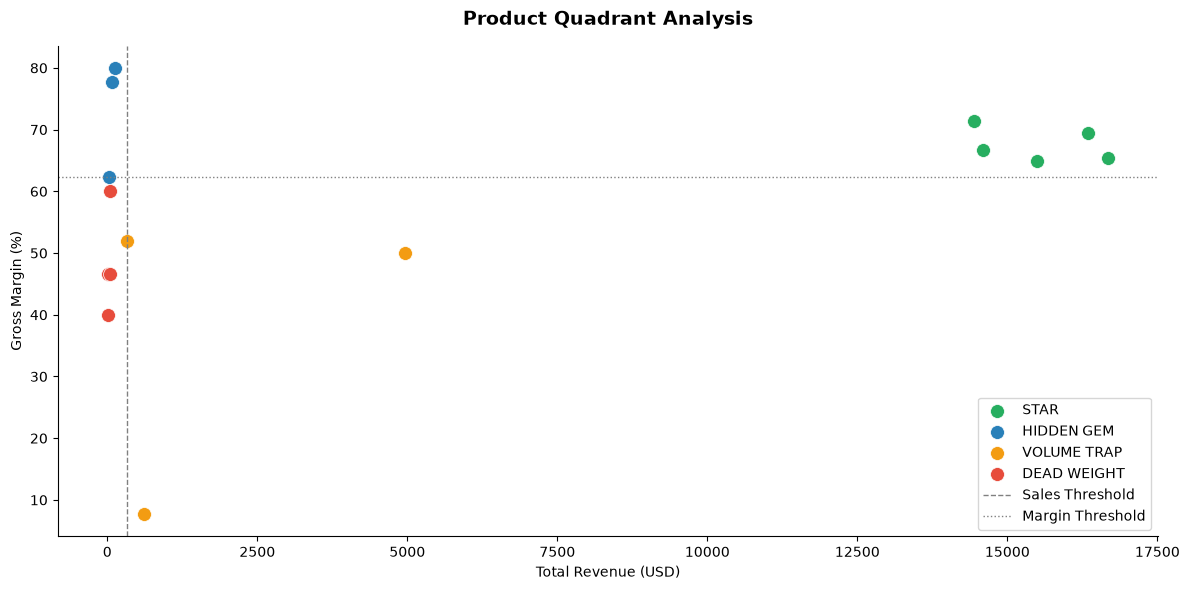

Chart 7 saved


In [6]:
fig, ax = plt.subplots()

for quadrant, color in QUADRANT_COLORS.items():
    subset = product_summary[product_summary['Quadrant'] == quadrant]
    ax.scatter(
        subset['Total_Revenue'],
        subset['Avg_Margin'],
        color=color,
        label=quadrant,
        s=100,
        edgecolors='white',
        linewidth=0.5
    )

# Threshold lines
sales_median  = product_summary['Total_Revenue'].median()
margin_median = product_summary['Avg_Margin'].median()

ax.axvline(x=sales_median,  color='grey', linestyle='--', linewidth=1, label='Sales Threshold')
ax.axhline(y=margin_median, color='grey', linestyle=':',  linewidth=1, label='Margin Threshold')

ax.set_title('Product Quadrant Analysis', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (USD)')
ax.set_ylabel('Gross Margin (%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/07_product_quadrant_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

### Chart 8: Revenue vs Profit per Product

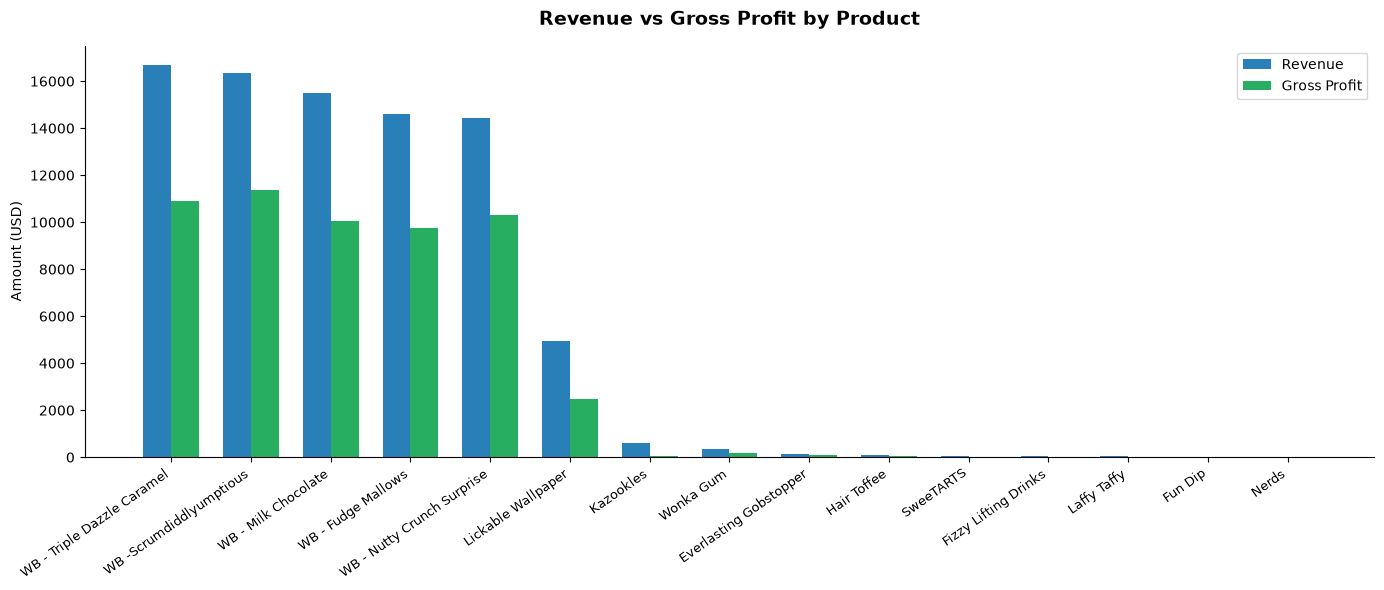

Chart 8 saved


In [7]:
ranked = product_summary.sort_values('Total_Revenue', ascending=False)

x     = np.arange(len(ranked))
width = 0.35

# Shorten product names for x axis
short_names = [name.replace('Wonka Bar - ', 'WB - ')
                   .replace('Wonka Bar -', 'WB -')
               for name in ranked['Product Name']]

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width/2, ranked['Total_Revenue'], width,
       color=COLORS['revenue'], label='Revenue')
ax.bar(x + width/2, ranked['Total_Profit'],  width,
       color=COLORS['profit'],  label='Gross Profit')

ax.set_title('Revenue vs Gross Profit by Product', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Amount (USD)')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/08_product_revenue_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

### Chart 9: Profit per Unit by Product

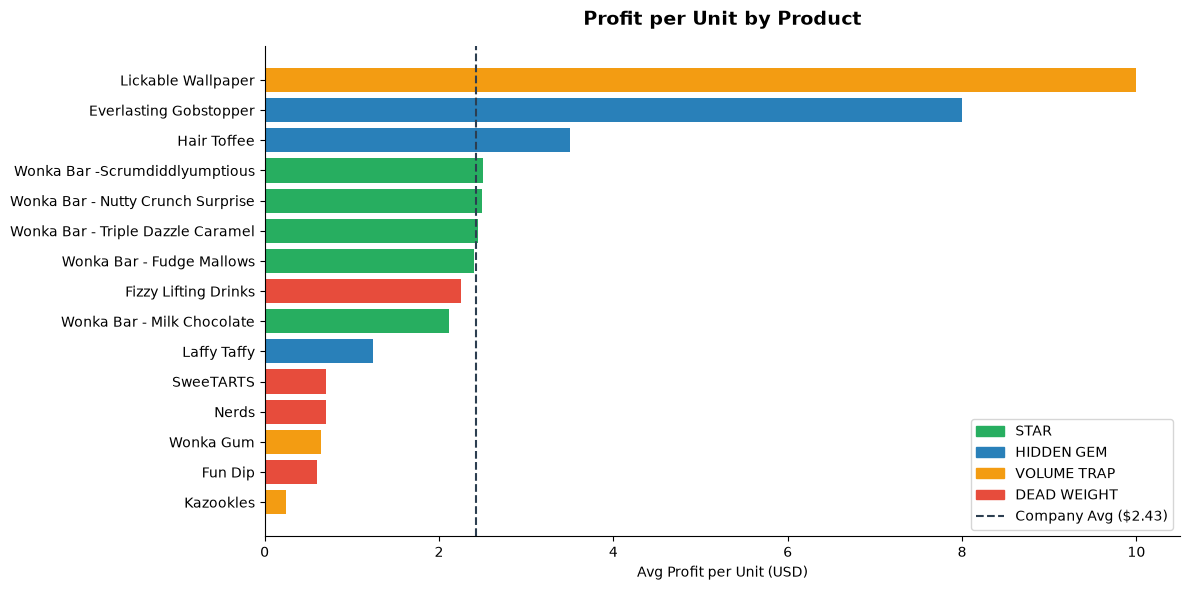

Chart 9 saved


In [8]:
ranked_ppu = product_summary.sort_values('Avg_Profit_per_Unit', ascending=True)

colors = [QUADRANT_COLORS[q] for q in ranked_ppu['Quadrant']]

fig, ax = plt.subplots()

ax.barh(ranked_ppu['Product Name'], ranked_ppu['Avg_Profit_per_Unit'], color=colors)

# Company average profit per unit
company_avg_ppu = total_profit / df['Units'].sum()
ax.axvline(x=company_avg_ppu, color=COLORS['primary'],
           linestyle='--', linewidth=1.5)

ax.set_title('Profit per Unit by Product', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Avg Profit per Unit (USD)')
ax.set_ylabel('')

legend_handles = [
    plt.Rectangle((0,0), 1, 1, color=color, label=quadrant)
    for quadrant, color in QUADRANT_COLORS.items()
]
legend_handles.append(
    plt.Line2D([0], [0], color=COLORS['primary'], linestyle='--',
               label=f'Company Avg (${company_avg_ppu:.2f})')
)
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/charts/09_product_profit_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved")